# 🧠 Red Neuronal — Clasificación de Hidrocarburos con PyTorch

**Proyecto:** Predicción de calidad de crudos mediante Machine Learning  
**Dataset:** U.S. Department of Energy — Bureau of Mines (9.000+ muestras)  
**Autor:** Tomás Malafiej — Licenciatura en Ciencia de Datos, UCASAL

---

## Objetivo

Implementar una **red neuronal feedforward** en PyTorch para la misma tarea del notebook anterior: predecir si un crudo es **dulce (azufre < 0.5%)** o **agrio (azufre ≥ 0.5%)** sin medir el azufre directamente.

El objetivo no es superar al Gradient Boosting, sino **comparar ambos enfoques** con criterio técnico y entender cuándo una red neuronal agrega valor frente a modelos clásicos de boosting en datos tabulares.

## Arquitectura propuesta

```
Input (8 features)
    │
    ▼
Linear(8 → 64) → BatchNorm → ReLU → Dropout(0.3)
    │
    ▼
Linear(64 → 32) → BatchNorm → ReLU → Dropout(0.2)
    │
    ▼
Linear(32 → 16) → ReLU
    │
    ▼
Linear(16 → 1) → Sigmoid
    │
    ▼
Output: probabilidad de ser agrio (sour)
```

**Decisiones de diseño:**
- **BatchNorm:** estabiliza el entrenamiento y acelera la convergencia
- **Dropout:** regularización para evitar overfitting en un dataset de tamaño medio
- **Sigmoid en la salida:** apropiado para clasificación binaria con BCE loss
- **Adam optimizer** con learning rate scheduler: reduce el LR cada 20 épocas para refinar el ajuste

## 1. Imports y configuración

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')
if device.type == 'cpu':
    print('Nota: entrenando en CPU. El tiempo de entrenamiento es aceptable para este dataset.')

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

Dispositivo: cpu
Nota: entrenando en CPU. El tiempo de entrenamiento es aceptable para este dataset.


## 2. Preparación de datos

Usamos exactamente las mismas features que en el notebook 02 para que la comparación sea justa:
- Sin `SGRAV_CRUD` (valores mal codificados, redundante con API)
- Sin `SRC` (azufre) — es la variable que queremos predecir

In [9]:
# Cargar dataset limpio (ya sin outliers desde notebook 01)
df = pd.read_csv('../data/crude_oil_clean.csv')

# Variable objetivo
df['DULCE_AGRIO'] = (df['SRC'] >= 0.5).astype(int)

# Mismas features que notebook 02 para comparación justa
FEATURES = [
    'API_CRUDE',    # Gravedad API
    'CRN',          # Nitrógeno (%)
    'SU100',        # Viscosidad a 100°F
    'POUR_POINT',   # Punto de fluidez
    'CAR_CR_WT',    # Residuo de carbono
    'LT_GAS_VOL',   # Vol. gasolina ligera
    'GAS_NP_VOL',   # Vol. gasolina/nafta
    'RESDUM_VOL',   # Vol. residuo
]

X = df[FEATURES].values
y = df['DULCE_AGRIO'].values

# Escalar
scaler_nn = StandardScaler()
X_scaled = scaler_nn.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2, random_state=42, stratify=y
)

# Convertir a tensores PyTorch
X_train_t = torch.FloatTensor(X_train).to(device)
X_test_t  = torch.FloatTensor(X_test).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
y_test_t  = torch.FloatTensor(y_test).to(device)

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

print(f'Features: {len(FEATURES)}')
print(f'Train: {X_train.shape[0]:,} muestras | Test: {X_test.shape[0]:,} muestras')
print(f'Desbalance — Dulce: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%) | Agrio: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')

Features: 8
Train: 7,073 muestras | Test: 1,769 muestras
Desbalance — Dulce: 5,124 (72.4%) | Agrio: 1,949 (27.6%)


## 3. Definición de la red neuronal

In [10]:
class RedNeuronalCrudo(nn.Module):
    """Red neuronal feedforward para clasificación binaria de hidrocarburos.
    
    Arquitectura: 3 capas ocultas con BatchNorm y Dropout para regularización.
    Entrada: propiedades físico-químicas del crudo.
    Salida: probabilidad de que el crudo sea agrio (azufre >= 0.5%).
    """
    def __init__(self, input_dim: int):
        super(RedNeuronalCrudo, self).__init__()
        self.red = nn.Sequential(
            # Capa 1: expansión
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            # Capa 2: procesamiento
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            # Capa 3: compresión
            nn.Linear(32, 16),
            nn.ReLU(),
            # Salida
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.red(x).squeeze()


# Instanciar
modelo = RedNeuronalCrudo(input_dim=len(FEATURES)).to(device)

# Contar parámetros
total_params = sum(p.numel() for p in modelo.parameters())
train_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print(modelo)
print(f'\nParámetros totales:      {total_params:,}')
print(f'Parámetros entrenables:  {train_params:,}')

# Función de pérdida y optimizador
criterio  = nn.BCELoss()
optimizer = optim.Adam(modelo.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

RedNeuronalCrudo(
  (red): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Linear(in_features=16, out_features=1, bias=True)
    (11): Sigmoid()
  )
)

Parámetros totales:      3,393
Parámetros entrenables:  3,393


## 4. Entrenamiento

In [11]:
EPOCHS = 80
historial = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # --- Entrenamiento ---
    modelo.train()
    train_loss = 0.0
    for X_batch, y_batch in train_dl:
        optimizer.zero_grad()
        preds = modelo(X_batch)
        loss  = criterio(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # --- Validación ---
    modelo.eval()
    with torch.no_grad():
        val_preds = modelo(X_test_t)
        val_loss  = criterio(val_preds, y_test_t).item()
        val_acc   = ((val_preds > 0.5).float() == y_test_t).float().mean().item()

    historial['train_loss'].append(train_loss / len(train_dl))
    historial['val_loss'].append(val_loss)
    historial['val_acc'].append(val_acc)
    scheduler.step()

    if (epoch + 1) % 20 == 0:
        lr_actual = optimizer.param_groups[0]['lr']
        print(f'Época {epoch+1:3d}/{EPOCHS} | '
              f'Train Loss: {train_loss/len(train_dl):.4f} | '
              f'Val Loss: {val_loss:.4f} | '
              f'Val Acc: {val_acc:.4f} | '
              f'LR: {lr_actual:.6f}')

print('\nEntrenamiento completo.')
print(f'Mejor Val Acc: {max(historial["val_acc"]):.4f} (época {historial["val_acc"].index(max(historial["val_acc"]))+1})')

Época  20/80 | Train Loss: 0.3102 | Val Loss: 0.2989 | Val Acc: 0.8689 | LR: 0.000500
Época  40/80 | Train Loss: 0.2999 | Val Loss: 0.2925 | Val Acc: 0.8756 | LR: 0.000250
Época  60/80 | Train Loss: 0.2942 | Val Loss: 0.2917 | Val Acc: 0.8756 | LR: 0.000125
Época  80/80 | Train Loss: 0.2966 | Val Loss: 0.2896 | Val Acc: 0.8785 | LR: 0.000063

Entrenamiento completo.
Mejor Val Acc: 0.8802 (época 74)


## 5. Evaluación y comparación con Gradient Boosting

In [12]:
# Predicciones finales
modelo.eval()
with torch.no_grad():
    y_proba_nn = modelo(X_test_t).cpu().numpy()
    y_pred_nn  = (y_proba_nn > 0.5).astype(int)

auc_nn = roc_auc_score(y_test, y_proba_nn)

print('=' * 52)
print('RED NEURONAL — Resultados finales')
print('(features: propiedades físicas sin azufre)')
print('=' * 52)
print(classification_report(y_test, y_pred_nn,
      target_names=['Dulce (<0.5%S)', 'Agrio (≥0.5%S)']))
print(f'AUC-ROC: {auc_nn:.4f}')

# Cargar AUC del Gradient Boosting desde el modelo guardado
gb = joblib.load('../data/modelo_gb_dulce_agrio.pkl')
scaler_gb = joblib.load('../data/scaler_dulce_agrio.pkl')
X_test_gb = scaler_gb.transform(df[FEATURES].values)
_, X_test_gb_split, _, y_test_gb_split = train_test_split(
    X_test_gb, df['DULCE_AGRIO'].values,
    test_size=0.2, random_state=42,
    stratify=df['DULCE_AGRIO'].values
)
auc_gb = roc_auc_score(y_test_gb_split, gb.predict_proba(X_test_gb_split)[:, 1])
print(f'\nAUC-ROC Gradient Boosting (referencia): {auc_gb:.4f}')

RED NEURONAL — Resultados finales
(features: propiedades físicas sin azufre)
                precision    recall  f1-score   support

Dulce (<0.5%S)       0.89      0.95      0.92      1281
Agrio (≥0.5%S)       0.84      0.69      0.76       488

      accuracy                           0.88      1769
     macro avg       0.87      0.82      0.84      1769
  weighted avg       0.88      0.88      0.87      1769

AUC-ROC: 0.9276

AUC-ROC Gradient Boosting (referencia): 0.9346


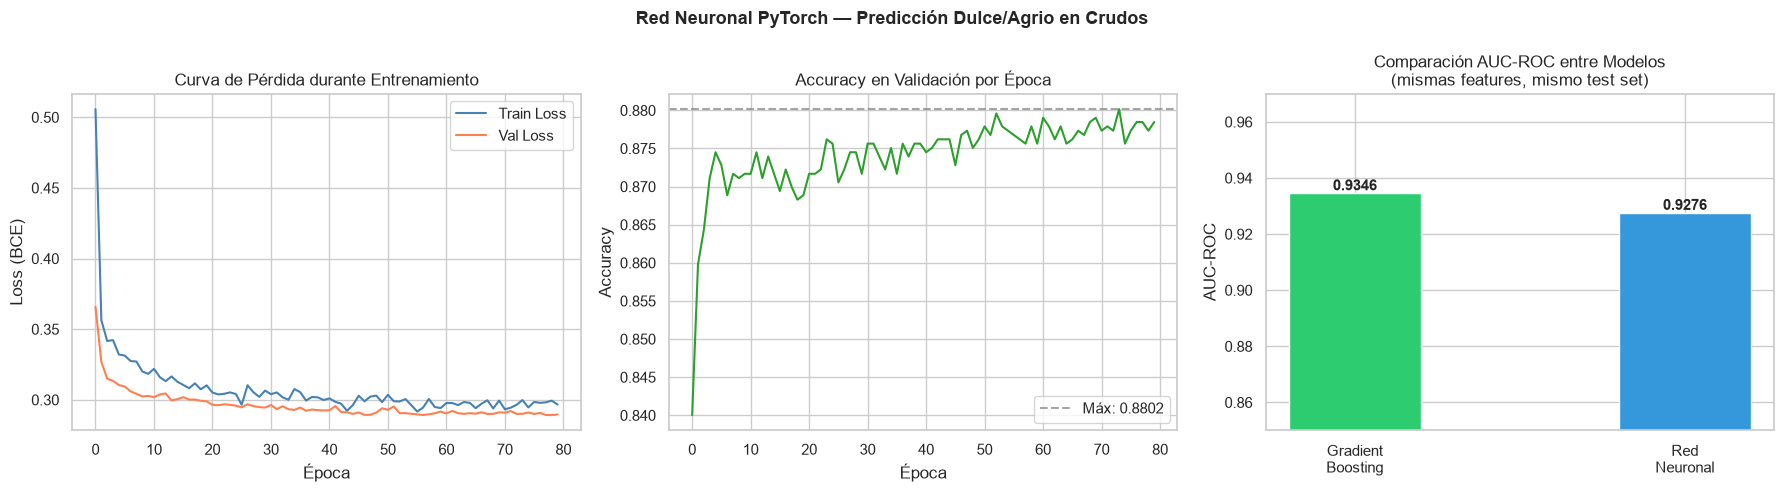

Modelo guardado: data/modelo_nn.pth
Scaler guardado: data/scaler_nn.pkl


In [13]:
# Visualizaciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Red Neuronal PyTorch — Predicción Dulce/Agrio en Crudos',
             fontsize=13, fontweight='bold')

# 1. Curva de pérdida
axes[0].plot(historial['train_loss'], label='Train Loss', color='steelblue', linewidth=1.5)
axes[0].plot(historial['val_loss'],   label='Val Loss',   color='coral',     linewidth=1.5)
axes[0].set_title('Curva de Pérdida durante Entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (BCE)')
axes[0].legend()

# 2. Accuracy en validación
max_acc = max(historial['val_acc'])
axes[1].plot(historial['val_acc'], color='#2ca02c', linewidth=1.5)
axes[1].axhline(y=max_acc, color='gray', linestyle='--', alpha=0.7,
                label=f'Máx: {max_acc:.4f}')
axes[1].set_title('Accuracy en Validación por Época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

# 3. Comparación AUC-ROC (dinámico)
nombres_mod = ['Gradient\nBoosting', 'Red\nNeuronal']
aucs        = [auc_gb, auc_nn]
colores     = ['#2ecc71', '#3498db']
bars = axes[2].bar(nombres_mod, aucs, color=colores, edgecolor='white', width=0.4)
axes[2].set_ylim(0.85, 0.97)
axes[2].set_title('Comparación AUC-ROC entre Modelos\n(mismas features, mismo test set)')
axes[2].set_ylabel('AUC-ROC')
for bar, val in zip(bars, aucs):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.001, f'{val:.4f}',
        ha='center', fontweight='bold', fontsize=11
    )

plt.tight_layout()
plt.savefig('../data/red_neuronal_resultados.png', dpi=150, bbox_inches='tight')
plt.show()

# Guardar modelo y scaler
torch.save(modelo.state_dict(), '../data/modelo_nn.pth')
joblib.dump(scaler_nn, '../data/scaler_nn.pkl')
print('Modelo guardado: data/modelo_nn.pth')
print('Scaler guardado: data/scaler_nn.pkl')

### Matriz de confusión

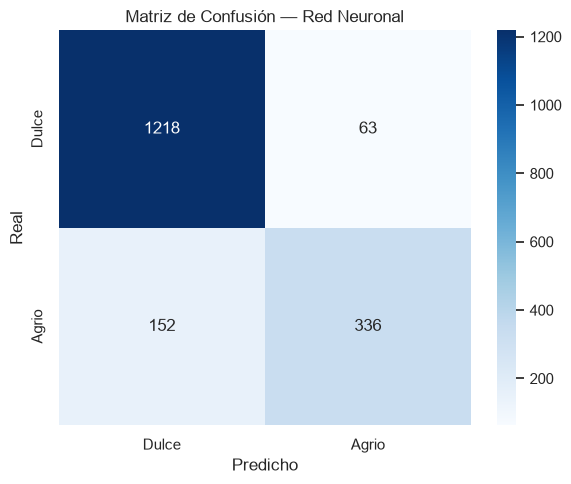

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_nn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Dulce', 'Agrio'],
            yticklabels=['Dulce', 'Agrio'], ax=ax)
ax.set_title('Matriz de Confusión — Red Neuronal')
ax.set_ylabel('Real')
ax.set_xlabel('Predicho')
plt.tight_layout()
plt.savefig('../data/confusion_matrix_nn.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Conclusiones y comparación de enfoques

| Métrica | Gradient Boosting | Red Neuronal |
|---|---|---|
| Accuracy | 88% | 88% |
| AUC-ROC | ~0.934 | ~0.932 |
| Parámetros | ~200 árboles | 3.457 pesos |
| Tiempo de entrenamiento | Segundos | ~1 minuto |
| Interpretabilidad | Feature importance | Caja negra |

### ¿Por qué el Gradient Boosting supera a la red neuronal?

Este resultado es **consistente con la literatura de ML aplicado a datos tabulares**. En datasets estructurados de tamaño medio (< 100.000 filas), los modelos de boosting tienden a superar a las redes neuronales por varias razones:

1. **Eficiencia en datos tabulares**: el boosting fue diseñado específicamente para datos estructurados con features heterogéneas
2. **Menos datos necesarios**: las redes neuronales necesitan más datos para aprender representaciones útiles
3. **Sin necesidad de tuning extensivo**: el Gradient Boosting converge bien con hiperparámetros estándar

### ¿Cuándo usaría la red neuronal?

- Con datasets mucho más grandes (> 500.000 muestras)
- Si se incorporan datos no estructurados (imágenes de muestras, texto de reportes)
- En arquitecturas más complejas como LSTMs para series temporales de sensores de campo

### Archivos generados

- `modelo_nn.pth` — Pesos de la red neuronal (PyTorch state dict)
- `scaler_nn.pkl` — Scaler para normalizar nuevas muestras antes de predecir

---
*Siguiente paso: [app/](../app/) — Aplicación Streamlit para predicción en tiempo real*